# ADTK Example Use

In [1]:
import pandas as pd
import time
import matplotlib.pyplot as plt

from time_series_generator import create_time_series_ensemble


from adtk.data import validate_series
from adtk.detector import SeasonalAD, QuantileAD, InterQuartileRangeAD, GeneralizedESDTestAD

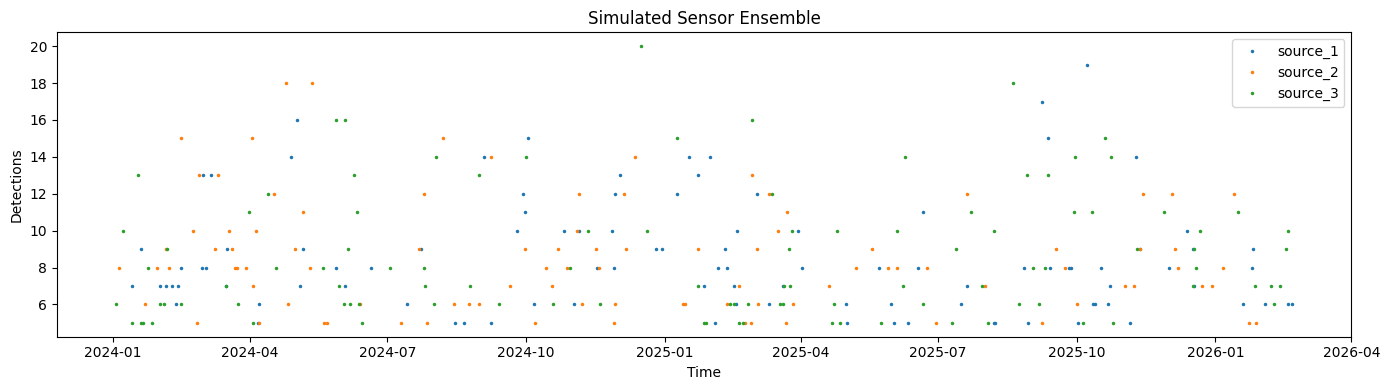

In [2]:
ts_raw = create_time_series_ensemble(
    start_date="2024-01-01",
    magnitude=5,
    floor=5,
    log_rates=[0.25, 0.23, 0.27],
    seasonal_cycles={7: 0.01, 365.25: 0.001},
    seed=int(time.time_ns()),
    y_label="source",
    plot=True,
)

In [ ]:
source_cols = [col for col in ts_raw.columns if col != "time"]

ts_sparse = ts_raw.set_index("time")
ts_sparse.index = pd.DatetimeIndex(ts_sparse.index)
ts_sparse = validate_series(ts_sparse)

sparse_index = ts_sparse.index  # original uneven observation dates; used to filter anomalies back to real points

daily_index = pd.date_range(ts_sparse.index.min(), ts_sparse.index.max(), freq="D")

ts_daily = (
    ts_sparse
    .reindex(daily_index)
    .interpolate(method="time")
    .ffill()
    .bfill()
)
ts_daily.index.name = "time"
ts_daily = validate_series(ts_daily)

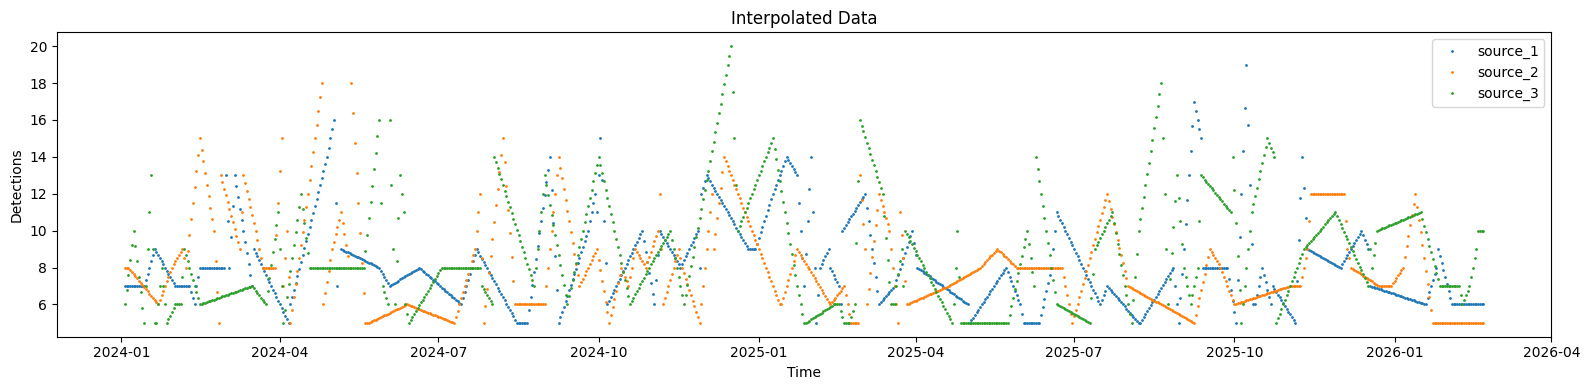

In [4]:
plt.figure(figsize=(16, 4))
for col in source_cols:  # Suggestion: replaced hardcoded ["source_1", ...] with source_cols
    plt.plot(ts_daily.index, ts_daily[col], ".", markersize=2, label=col)
plt.title("Interpolated Data")
plt.xlabel("Time")
plt.ylabel("Detections")
plt.legend()
plt.tight_layout()
plt.show()

In [5]:
seasonal_ad = SeasonalAD(freq=7)
seasonal_anomalies = seasonal_ad.fit_detect(ts_daily)
seasonal_anomalies = seasonal_anomalies[
    seasonal_anomalies.index.isin(sparse_index) & seasonal_anomalies.astype(bool).any(axis=1)
]

2026-02-28 13:15:27,849 - adtk.detector._detector_1d - INFO - IQRAD initialized with lower_factor=None, upper_factor=3.0
2026-02-28 13:15:27,849 - adtk.detector._detector_1d - INFO - IQRAD fitting started: 781 non-null points
2026-02-28 13:15:27,851 - adtk.detector._detector_1d - INFO - Computed quartiles: Q1=0.6467, Q3=2.2467, IQR=1.6000
2026-02-28 13:15:27,851 - adtk.detector._detector_1d - INFO - IQRAD Thresholds set: abs_low_=-inf, abs_high_=7.0467
2026-02-28 13:15:27,854 - adtk.detector._detector_1d - INFO - IQRAD initialized with lower_factor=None, upper_factor=3.0
2026-02-28 13:15:27,854 - adtk.detector._detector_1d - INFO - IQRAD fitting started: 781 non-null points
2026-02-28 13:15:27,855 - adtk.detector._detector_1d - INFO - Computed quartiles: Q1=0.7002, Q3=2.7302, IQR=2.0300
2026-02-28 13:15:27,856 - adtk.detector._detector_1d - INFO - IQRAD Thresholds set: abs_low_=-inf, abs_high_=8.8202
2026-02-28 13:15:27,858 - adtk.detector._detector_1d - INFO - IQRAD initialized with l

In [6]:
quantile_ad = QuantileAD(high=0.99, low=0.01)
quantile_anomalies = quantile_ad.fit_detect(ts_sparse)
quantile_anomalies = quantile_anomalies[
    quantile_anomalies.index.isin(sparse_index) & quantile_anomalies.astype(bool).any(axis=1)
]

2026-02-28 13:15:27,887 - adtk.detector._detector_1d - INFO - QuantileAD initialized with low_quantile=0.01, high_quantile=0.99
2026-02-28 13:15:27,887 - adtk.detector._detector_1d - INFO - QuantileAD fitting started: 100 non-null points
2026-02-28 13:15:27,888 - adtk.detector._detector_1d - INFO - Fitted low quantile (0.01): 5.0000
2026-02-28 13:15:27,889 - adtk.detector._detector_1d - INFO - Fitted high quantile (0.99): 17.0200
2026-02-28 13:15:27,889 - adtk.detector._detector_1d - INFO - QuantileAD initialized with low_quantile=0.01, high_quantile=0.99
2026-02-28 13:15:27,889 - adtk.detector._detector_1d - INFO - QuantileAD fitting started: 97 non-null points
2026-02-28 13:15:27,890 - adtk.detector._detector_1d - INFO - Fitted low quantile (0.01): 5.0000
2026-02-28 13:15:27,891 - adtk.detector._detector_1d - INFO - Fitted high quantile (0.99): 18.0000
2026-02-28 13:15:27,891 - adtk.detector._detector_1d - INFO - QuantileAD initialized with low_quantile=0.01, high_quantile=0.99
2026-

In [7]:
iqr_ad = InterQuartileRangeAD(c=1.5)
iqr_anomalies = iqr_ad.fit_detect(ts_sparse)
iqr_anomalies = iqr_anomalies[
    iqr_anomalies.index.isin(sparse_index) & iqr_anomalies.astype(bool).any(axis=1)
]

2026-02-28 13:15:27,905 - adtk.detector._detector_1d - INFO - IQRAD initialized with symmetric factor=1.50
2026-02-28 13:15:27,906 - adtk.detector._detector_1d - INFO - IQRAD fitting started: 100 non-null points
2026-02-28 13:15:27,907 - adtk.detector._detector_1d - INFO - Computed quartiles: Q1=6.0000, Q3=10.0000, IQR=4.0000
2026-02-28 13:15:27,907 - adtk.detector._detector_1d - INFO - IQRAD Thresholds set: abs_low_=0.0000, abs_high_=16.0000
2026-02-28 13:15:27,908 - adtk.detector._detector_1d - INFO - IQRAD initialized with symmetric factor=1.50
2026-02-28 13:15:27,908 - adtk.detector._detector_1d - INFO - IQRAD fitting started: 97 non-null points
2026-02-28 13:15:27,910 - adtk.detector._detector_1d - INFO - Computed quartiles: Q1=6.0000, Q3=10.0000, IQR=4.0000
2026-02-28 13:15:27,910 - adtk.detector._detector_1d - INFO - IQRAD Thresholds set: abs_low_=0.0000, abs_high_=16.0000
2026-02-28 13:15:27,910 - adtk.detector._detector_1d - INFO - IQRAD initialized with symmetric factor=1.50


In [8]:
esd_ad = GeneralizedESDTestAD(alpha=0.3)
esd_anomalies = esd_ad.fit_detect(ts_daily)
esd_anomalies = esd_anomalies[
    esd_anomalies.index.isin(sparse_index) & esd_anomalies.astype(bool).any(axis=1)
]

In [ ]:
def plot_anomalies(
    anomaly_sets,
    source_cols,
    ts_sparse,
    ts_daily,
    use_interpolated=False,  # Suggestion: renamed `interpolated` -> `use_interpolated` (clearer it's a flag)
):
    plot_data = ts_daily if use_interpolated else ts_sparse

    axes = plt.subplots(len(anomaly_sets), 1, figsize=(15, 4 * len(anomaly_sets)))

    for ax, (anomalies, title) in zip(axes, anomaly_sets):
        for col in source_cols:
            ax.plot(plot_data.index, plot_data.loc[date, col], linewidth=0.8, label=col)

        for date in anomalies[anomalies.any(axis=1)].index:
            flagged_cols = anomalies.loc[date]
            flagged_cols = flagged_cols[flagged_cols == 1.0].index
            for col in flagged_cols:
                ax.scatter(date, ts_sparse.loc[date, col], color="red", s=40, zorder=5)

        ax.set_title(title)
        ax.set_xlabel("Date")
        ax.set_ylabel("Detections")
        ax.legend()

    plt.tight_layout()
    plt.show()

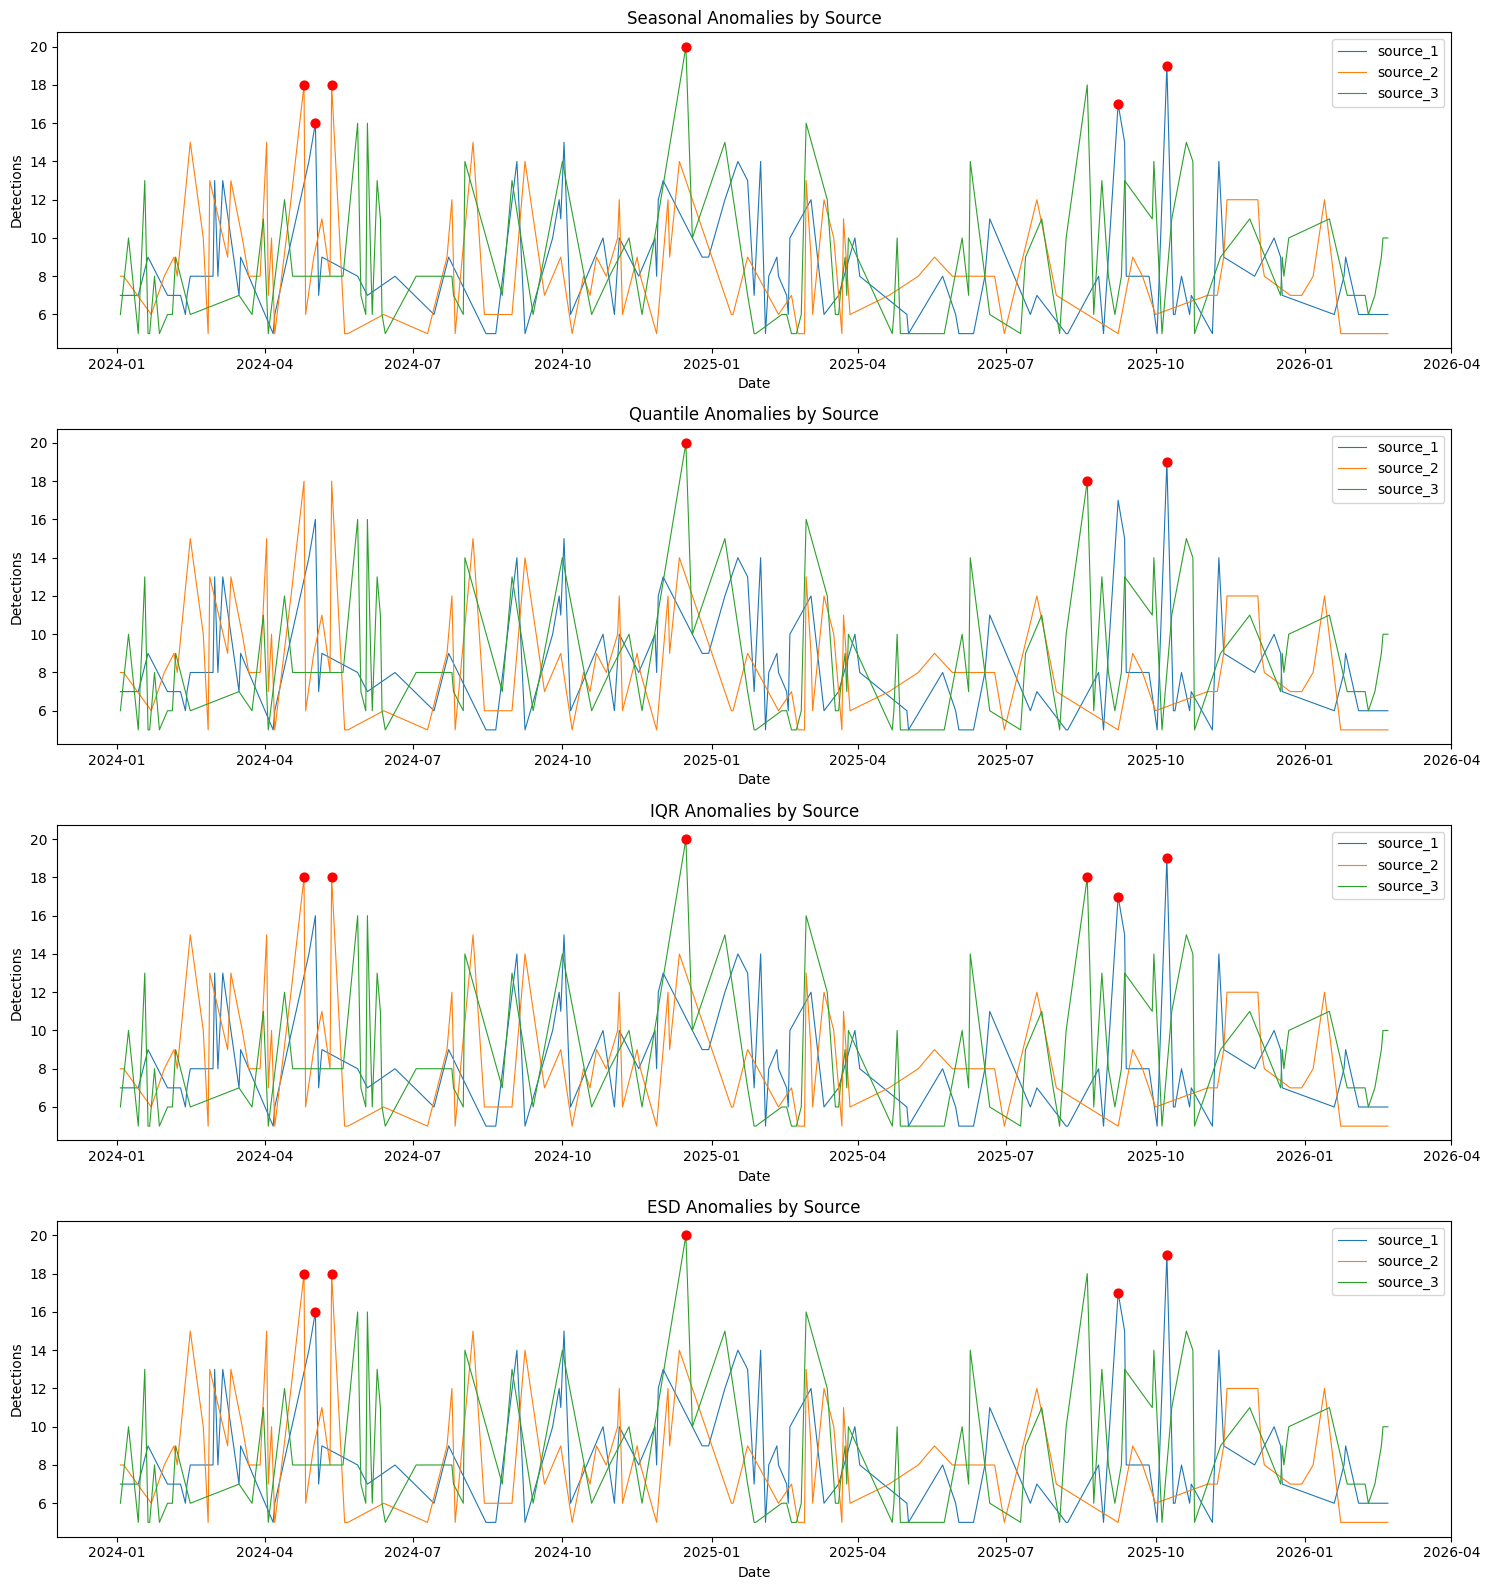

In [10]:
plot_anomalies(
    anomaly_sets=[
        (seasonal_anomalies, "Seasonal Anomalies by Source"),
        (quantile_anomalies, "Quantile Anomalies by Source"),
        (iqr_anomalies, "IQR Anomalies by Source"),
        (esd_anomalies, "ESD Anomalies by Source"),
    ],
    source_cols=source_cols,
    ts_sparse=ts_sparse,
    ts_daily=ts_daily,
    use_interpolated=True,
)